# Exemplar: Effectuer une régression linéaire multiple


## Introduction

l'analyse des données historiques de promotion marketing d'une petite entreprise. Chaque ligne correspond à une promotion marketing indépendante dans le cadre de laquelle l'entreprise utilise la télévision, les médias sociaux, la radio et les promotions d'influenceurs pour augmenter ses ventes. Etendrant cette analyse pour inclure d'autres variables qui peuvent les aider à cibler leurs efforts de marketing.

Il s'agira notamment de :

* Explorer et nettoyer les données
* Utiliser des graphiques et des statistiques descriptives pour sélectionner les variables indépendantes
* Créer un modèle de régression linéaire multiple adapté
* Vérifier les hypothèses du modèle
* Interpréter les résultats du modèle et communiquer les résultats aux parties prenantes non techniques.

## Étape 1 : Imports

In [ ]:
%pip install pandas matplotlib seaborn statsmodels

### Import packages

Importer les bibliothèques et modules Python appropriés.

On a choisi d’utiliser 'ols' de **statsmodels.formula.api** au lieu de **OLS** car cela permet d’écrire la régression sous forme de formule **('Y ~ X1 + X2')**, ce qui est plus lisible et adapté à la modélisation multivariée sur un DataFrame. Les deux approches sont équivalentes, mais ols simplifie la syntaxe et gère automatiquement l’ajout de la constante.


In [ ]:
# Import libraries and modules.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

### Load dataset

Chargez l'ensemble de données `marketing_sales_data.csv` en tant que `data` et affichez les cinq premières lignes. Les variables de l'ensemble de données ont été ajustées pour répondre aux objectifs de ce laboratoire.

In [ ]:
# Load the data.

data = pd.read_csv('marketing_sales_data.csv')

# Display the first five rows.

data.head()

,TV,Radio,Social Media,Influencer,Sales
0,16.0,6.566231,2.907983,Mega,54.732757
1,13.0,9.237765,2.409567,Mega,46.677897
2,41.0,15.886446,2.913410,Mega,150.177829
3,83.0,30.020028,6.922304,Mega,298.246340
4,15.0,8.437408,1.405998,Micro,56.594181


In [28]:
# Divide the TV column into High, Medium, and Low categories.
data['TV'] = pd.cut(data['TV'], 
                    bins=[0, 33, 66, float('inf')], 
                    labels=['Low', 'Medium', 'High'])

# Display the first few rows to verify the changes.
data.head()

,TV,Radio,Social Media,Influencer,Sales
0,Low,6.566231,2.907983,Mega,54.732757
1,Low,9.237765,2.409567,Mega,46.677897
2,Medium,15.886446,2.913410,Mega,150.177829
3,High,30.020028,6.922304,Mega,298.246340
4,Low,8.437408,1.405998,Micro,56.594181


## Étape 2 : Exploration des données

### Familiarisez-vous avec les caractéristiques des données

Commencez par une analyse exploratoire des données.

Les caractéristiques des données sont les suivantes

* Budget promotionnel à la télévision (dans les catégories "faible", "moyen" et "élevé")
* Budget promotionnel sur les médias sociaux (en millions de dollars)
* Budget promotionnel à la radio (en millions de dollars)
* Ventes (en millions de dollars)
* Taille de l'influenceur (dans les catégories "méga", "macro", "micro" et "nano")

### Créer un diagramme de paires de données

Créer un diagramme de paires pour visualiser la relation entre les variables continues dans `data`.

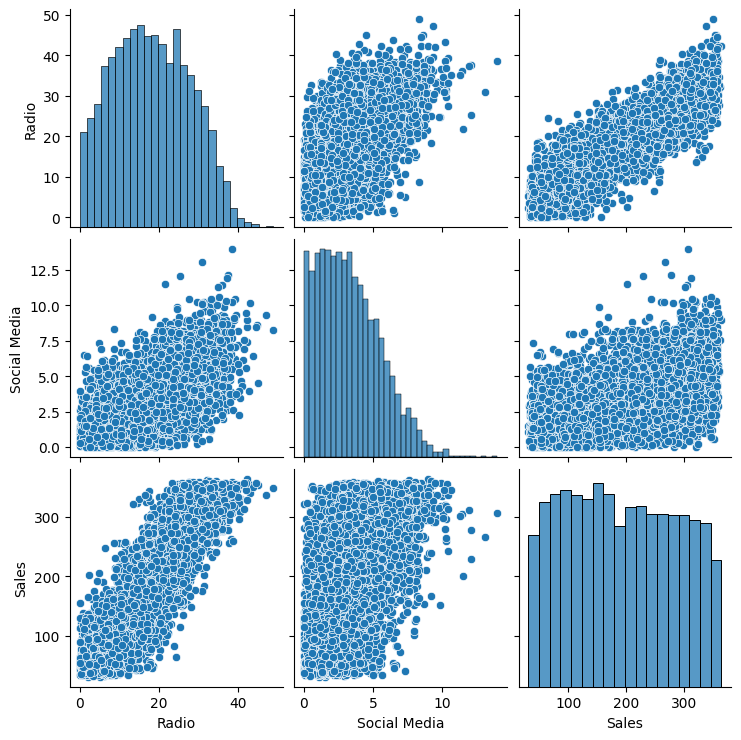

In [ ]:
# Create a pairplot of the data.

sns.pairplot(data);

**Question:** Quelles variables ont une relation linéaire avec le chiffre d'affaires ? Pourquoi certaines variables des données sont-elles exclues du graphique précédent ?

Les variables `Radio` et `Médias sociaux` semblent toutes deux avoir une relation linéaire avec les `Ventes`. Par conséquent, la `Radio` et les `Médias sociaux` peuvent être utiles en tant que variables indépendantes dans un modèle de régression linéaire multiple estimant les `Ventes`. 

Les variables `TV` et `Influencer` sont exclues du graphique en paires car elles ne sont pas numériques.

### Calculer la moyenne des ventes pour chaque variable catégorielle

In [ ]:
# Calculate the mean sales for each TV category. 

print(data.groupby('TV')['Sales'].mean())

print('')

# Calculate the mean sales for each Influencer category .

print(data.groupby('Influencer')['Sales'].mean())

TV
Low        77.040542
Medium    176.748906
High      297.702390
Name: Sales, dtype: float64

Influencer
Macro    195.613601
Mega     190.593666
Micro    191.809095
Nano     191.934304
Name: Sales, dtype: float64


C:\Users\ChamsYAHIA\AppData\Local\Temp\ipykernel_38872\1890808078.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(data.groupby('TV')['Sales'].mean())


**Question:** Quel remarque à propos des variables catégorielles ? Pourraient-elles être utiles pour prédire les ventes ?

Le chiffre d'affaires moyen des promotions à « TV élevée » est considérablement plus élevé que celui des promotions à « TV moyenne » et « TV faible ». La `TV` peut être un facteur prédictif important des `Ventes`.

Les catégories pour `Influenceur` ont des moyennes de `Ventes` différentes, mais la variation n'est pas substantielle. L'indicateur `Influenceur` peut être une faible variable prédictive des `Ventes`.

Ces résultats peuvent être étudiés plus en détail lors de l'ajustement du modèle de régression linéaire multiple.

### Supprimer les données manquantes

In [ ]:
# Drop rows that contain missing data and update the DataFrame.


data = data.dropna(axis=0)

### Nettoyer les noms de colonnes

La fonction `ols()` ne s'exécute pas lorsque les noms de variables contiennent un espace.

In [ ]:
# Rename all columns in data that contain a space. 


data = data.rename(columns={'Social Media': 'Social_Media'})

## Étape 3 : Construction du modèle

### Ajuster un modèle de régression linéaire multiple qui prédit les ventes

In [ ]:
# Define the OLS formula.


ols_formula = 'Sales ~ C(TV) + Radio'

# Create an OLS model.


OLS = ols(formula = ols_formula, data = data)

# Fit the model.


model = OLS.fit()

# Save the results summary.


model_results = model.summary()

# Display the model results.


model_results

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.913
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                 1.592e+04
Date:                Fri, 04 Apr 2025   Prob (F-statistic):               0.00
Time:                        22:24:06   Log-Likelihood:                -21502.
No. Observations:                4546   AIC:                         4.301e+04
Df Residuals:                    4542   BIC:                         4.304e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          52.4515      0.974     53.873      0.000      50.543      54.360
C(TV)[T.Medium]    74.2895      1.188     62.534      0.000      71.960      76.618
C(TV)[T.High]     160.3908      1.761     91.071      0.000     156.938     163.844
Radio               3.0526      0.072     42.363      0.000       2.911       3.194
==============================================================================
Omnibus:                      102.196   Durbin-Watson:                   2.004
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               53.917
Skew:                           0.031   Prob(JB):                     1.96e-12
Kurtosis:                       2.470   Cond. No.                         101.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Question:** Quelles variables indépendantes à choisir pour le modèle, et pourquoi ?

* Le choix s'est porté sur `TV`, car l'analyse précédente a montré une forte relation entre le budget promotionnel de `TV` et la moyenne des `Ventes`.
* `Radio` a été choisi car le graphique en paires a montré une forte relation linéaire entre `Radio` et `Ventes`.
* Les médias sociaux n'ont pas été sélectionnés car ils n'ont pas augmenté la performance du modèle et il a été déterminé plus tard qu'ils étaient corrélés avec une autre variable indépendante : `Radio`.
* L'influenceur n'a pas été sélectionné parce qu'il n'a pas montré une forte relation avec les ventes dans l'analyse précédente.

### Vérifier les hypothèses du modèle

### Hypothèse du modèle : Linéarité

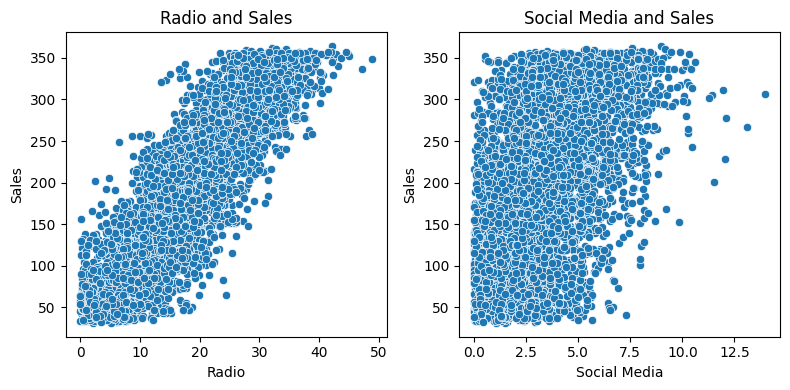

In [ ]:
# Create a scatterplot for each independent variable and the dependent variable.


# Create a 1x2 plot figure.
fig, axes = plt.subplots(1, 2, figsize = (8,4))

# Create a scatterplot between Radio and Sales.
sns.scatterplot(x = data['Radio'], y = data['Sales'],ax=axes[0])

# Set the title of the first plot.
axes[0].set_title("Radio and Sales")

# Create a scatterplot between Social Media and Sales.
sns.scatterplot(x = data['Social_Media'], y = data['Sales'],ax=axes[1])

# Set the title of the second plot.
axes[1].set_title("Social Media and Sales")

# Set the xlabel of the second plot.
axes[1].set_xlabel("Social Media")

# Use matplotlib's tight_layout() function to add space between plots for a cleaner appearance.
plt.tight_layout()


**Question:** L'hypothèse de linéarité est-elle respectée ?

L'hypothèse de linéarité est respectée pour `Radio`, car il existe une relation linéaire claire dans le nuage de points entre `Radio` et `Ventes`. Les « médias sociaux » n'ont pas été inclus dans le modèle de régression linéaire multiple précédent, mais ils semblent avoir une relation linéaire avec les « ventes ».

### Hypothèse du modèle : Indépendance

L'**hypothèse d'observation indépendante** stipule que chaque observation de l'ensemble de données est indépendante. Comme chaque promotion commerciale (c'est-à-dire chaque ligne) est indépendante les unes des autres, l'hypothèse d'indépendance n'est pas violée.

### Hypothèse du modèle : Normalité

Créez les graphiques suivants pour vérifier l'hypothèse de **normalité** :

* **plot 1** : Histogramme des résidus
* **plot 2** : Graphique Q-Q des résidus

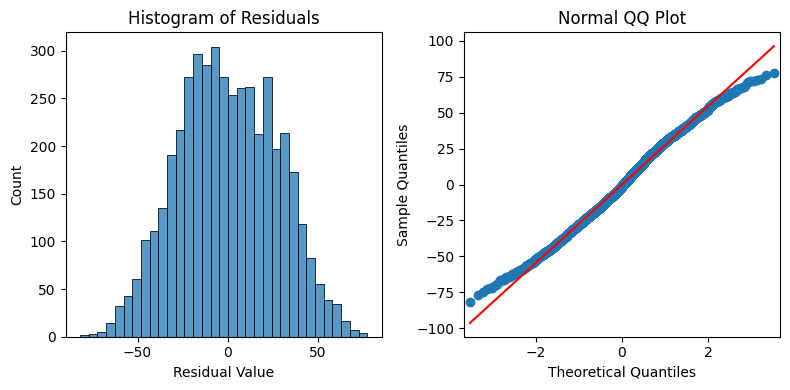

In [ ]:
# Calculate the residuals.


residuals = model.resid

# Create a 1x2 plot figure.
fig, axes = plt.subplots(1, 2, figsize = (8,4))

# Create a histogram with the residuals. 


sns.histplot(residuals, ax=axes[0])

# Set the x label of the residual plot.
axes[0].set_xlabel("Residual Value")

# Set the title of the residual plot.
axes[0].set_title("Histogram of Residuals")

# Create a Q-Q plot of the residuals.


sm.qqplot(residuals, line='s',ax = axes[1])

# Set the title of the Q-Q plot.
axes[1].set_title("Normal QQ Plot")

# Use matplotlib's tight_layout() function to add space between plots for a cleaner appearance.
plt.tight_layout()

# Show the plot.
plt.show()

**Question:** L'hypothèse de normalité est-elle respectée ?

L'histogramme des résidus est approximativement distribué normalement, ce qui confirme que l'hypothèse de normalité est respectée pour ce modèle. Les résidus dans le graphique Q-Q forment une ligne droite, ce qui confirme que cette hypothèse est respectée.

### Hypothèse du modèle : Variance constante

Vérifiez que l'hypothèse de variance constante n'est pas violée en créant un nuage de points avec les valeurs ajustées et les résidus. Ajoutez une ligne à $y = 0$ pour visualiser la variance des résidus au-dessus et au-dessous de $y = 0$.

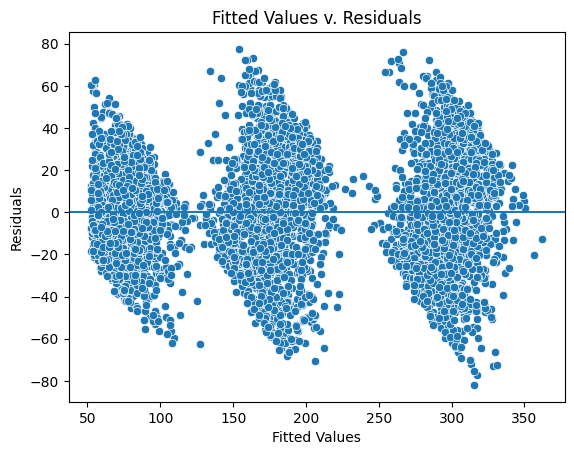

In [ ]:
# Create a scatterplot with the fitted values from the model and the residuals.


fig = sns.scatterplot(x = model.fittedvalues, y = model.resid)

# Set the x axis label.
fig.set_xlabel("Fitted Values")

# Set the y axis label.
fig.set_ylabel("Residuals")

# Set the title.
fig.set_title("Fitted Values v. Residuals")

# Add a line at y = 0 to visualize the variance of residuals above and below 0.


fig.axhline(0)

# Show the plot.
plt.show()

**Question 7:** L'hypothèse de variance constante est-elle respectée ?

Les valeurs ajustées sont réparties en trois groupes car la variable catégorielle est dominante dans ce modèle, ce qui signifie que la télévision est le facteur le plus important qui détermine les ventes.

Cependant, la variance là où il y a des valeurs ajustées est distribuée de façon similaire, ce qui confirme que l'hypothèse est respectée.

### Hypothèse du modèle : Pas de multicolinéarité

**L'hypothèse de non-collinéarité** stipule que deux variables indépendantes ($X_i$ et $X_j$) ne peuvent pas être fortement corrélées l'une à l'autre. 

Les deux méthodes les plus courantes pour vérifier la multicolinéarité sont les suivantes : * Créer des diagrammes de dispersion pour montrer la relation entre les paires de variables indépendantes :

* Créer des diagrammes de dispersion pour montrer la relation entre les paires de variables indépendantes
* Utiliser le facteur d'inflation de la variance pour détecter la multicolinéarité

Utilisez l'une de ces deux méthodes pour vérifier l'absence d'hypothèse de multicolinéarité de votre modèle.

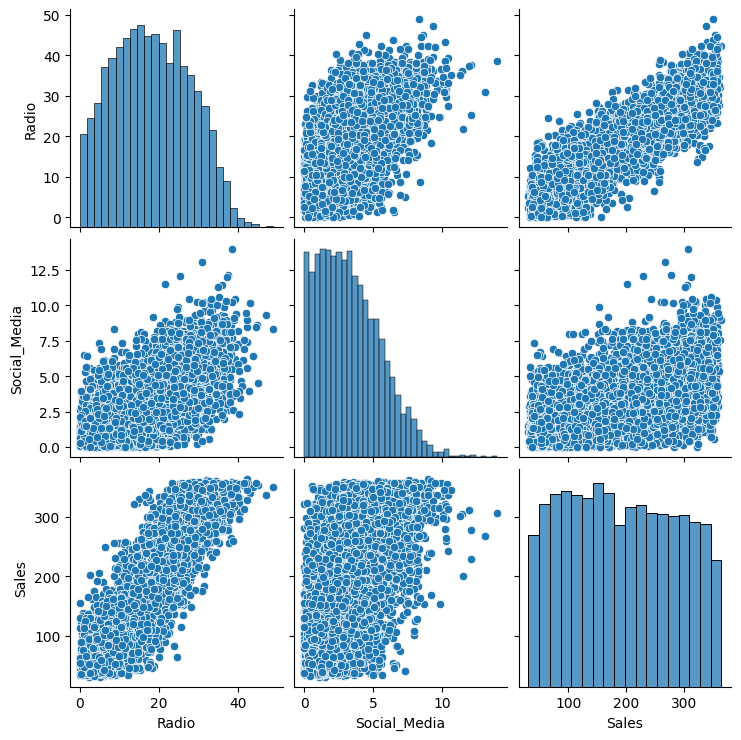

In [ ]:
# Create a pairplot of the data.

sns.pairplot(data)

In [ ]:
# Calculate the variance inflation factor (optional).


# Import variance_inflation_factor from statsmodels.
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create a subset of the data with the continous independent variables. 
X = data[['Radio','Social_Media']]

# Calculate the variance inflation factor for each variable.
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Create a DataFrame with the VIF results for the column names in X.
df_vif = pd.DataFrame(vif, index=X.columns, columns = ['VIF'])

# Display the VIF results.
df_vif

,VIF
Radio,4.927036
Social_Media,4.927036


**Question 8:** L'hypothèse d'absence de multicolinéarité est-elle respectée ?

Le modèle précédent ne comporte qu'une seule variable indépendante continue, ce qui signifie qu'il n'y a pas de problème de multicolinéarité. 

Si un modèle utilisait à la fois `Radio` et `Social_Media` comme prédicteurs, il y aurait une relation linéaire modérée entre `Radio` et `Social_Media` qui violerait l'hypothèse de multicollinéarité. En outre, le facteur d'inflation de la variance lorsque `Radio` et `Social_Media` sont inclus dans le modèle est de 4,9 pour chaque variable, ce qui indique une forte multicolinéarité.

## Step 4: Results and evaluation

### Display the OLS regression results

If the model assumptions are met, you can interpret the model results accurately.

First, display the OLS regression results.

In [39]:
# Display the model results summary.

### YOUR CODE HERE ### 

model_results

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.913
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                 1.592e+04
Date:                Fri, 04 Apr 2025   Prob (F-statistic):               0.00
Time:                        22:24:06   Log-Likelihood:                -21502.
No. Observations:                4546   AIC:                         4.301e+04
Df Residuals:                    4542   BIC:                         4.304e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          52.4515      0.974     53.873      0.000      50.543      54.360
C(TV)[T.Medium]    74.2895      1.188     62.534      0.000      71.960      76.618
C(TV)[T.High]     160.3908      1.761     91.071      0.000     156.938     163.844
Radio               3.0526      0.072     42.363      0.000       2.911       3.194
==============================================================================
Omnibus:                      102.196   Durbin-Watson:                   2.004
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               53.917
Skew:                           0.031   Prob(JB):                     1.96e-12
Kurtosis:                       2.470   Cond. No.                         101.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

 **Question:** Quelle est l'interprétation du R-carré du modèle ?

En utilisant `TV` et `Radio` comme variables indépendantes, on obtient un modèle de régression linéaire multiple avec $R^{2} = 0,913$. En d'autres termes, le modèle explique 91,3 % de la variation des ventes. Le modèle est donc un excellent prédicteur des ventes.

### Interpréter les coefficients du modèle

Une fois l'ajustement du modèle évalué, on peut examiner les estimations des coefficients et l'incertitude de ces estimations.

Affichez à nouveau les résultats de la régression par les MCO.

In [ ]:
# Display the model results summary.


model_results

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.913
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                 1.592e+04
Date:                Fri, 04 Apr 2025   Prob (F-statistic):               0.00
Time:                        22:24:06   Log-Likelihood:                -21502.
No. Observations:                4546   AIC:                         4.301e+04
Df Residuals:                    4542   BIC:                         4.304e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          52.4515      0.974     53.873      0.000      50.543      54.360
C(TV)[T.Medium]    74.2895      1.188     62.534      0.000      71.960      76.618
C(TV)[T.High]     160.3908      1.761     91.071      0.000     156.938     163.844
Radio               3.0526      0.072     42.363      0.000       2.911       3.194
==============================================================================
Omnibus:                      102.196   Durbin-Watson:                   2.004
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               53.917
Skew:                           0.031   Prob(JB):                     1.96e-12
Kurtosis:                       2.470   Cond. No.                         101.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Question:** Quels sont les coefficients du modèle ?

Lorsque `TV` et `Radio` sont utilisés pour prédire `Ventes`, les coefficients du modèle sont :

* $\beta_{0} = 52.4515$
* $\beta_{TVHigh}= 160.3908$
* $\beta_{TVMedium} = 74.2895$
* $\beta_{Radio} = 3.0526$

**Question:** Comment écrir la relation entre « Ventes » et les variables indépendantes sous forme d'équation linéaire ?

$\text{Sales} = \beta_{0} + \beta_{1}*X_{1}+ \beta_{2}*X_{2}+ \beta_{3}*X_{3}$

$\text{Sales} = \beta_{0} + \beta_{TVHigh}*X_{TVHigh}+ \beta_{TVMedium}*X_{TVMedium}+ \beta_{Radio}*X_{Radio}$

$\text{Sales} = 52.4515 + 160.3908*X_{TVLow} - 74.2895*X_{TVMedium}+ 3.0526 *X_{Radio}$

**Question:** Comment interpréter les estimations des coefficients ? Les coefficients sont-ils statistiquement significatifs ?

La catégorie `TV` par défaut du modèle est `High` puisqu'il y a des coefficients pour les deux autres catégories `TV`, `Medium` et `Low`. Comme les coefficients pour les catégories `Medium` et `Low` sont faibles, cela signifie que la moyenne des ventes est inférieure pour les catégories `Medium` ou `Low` par rapport à la catégorie `High` `TV` lorsque `Radio` est au même niveau.

Par exemple, le modèle prédit qu'une promotion `Low` `TV` est inférieure de 52,4515 en moyenne à une promotion `High` `TV` pour une même promotion `Radio`.

Le coefficient de `Radio` est positif, ce qui confirme la relation linéaire positive démontrée précédemment lors de l'analyse exploratoire des données.

La valeur p pour tous les coefficients est de 0,000$, ce qui signifie que tous les coefficients sont statistiquement significatifs à 0,05$. Les intervalles de confiance à 95 % pour chaque coefficient doivent être indiqués lors de la présentation des résultats aux parties prenantes. 

Par exemple, il y a 95 % de chances que l'intervalle $[50,54]$ contienne le véritable paramètre de la pente de $\beta_{TVLow}$, qui est la différence estimée dans les ventes promotionnelles lorsqu'une promotion ``Faible`` est choisie au lieu d'une promotion ``Haute``.

**Question:** Pourquoi est-il important d'interpréter les coefficients bêta ?

Les coefficients bêta vous permettent d'estimer l'ampleur et la direction (positive ou négative) de l'effet de chaque variable indépendante sur la variable dépendante. Les estimations des coefficients peuvent être converties en informations explicables, telles que le lien entre l'augmentation des budgets de promotion télévisuelle et les ventes mentionné précédemment.

## Considerations

* La régression linéaire multiple est un outil puissant pour estimer une variable continue dépendante à partir de plusieurs variables indépendantes.
* L'analyse exploratoire des données est utile pour sélectionner les caractéristiques numériques et catégorielles pour la régression linéaire multiple.
* L'ajustement des modèles de régression linéaire multiple peut nécessiter des essais et des erreurs pour sélectionner les variables qui correspondent à un modèle précis tout en maintenant les hypothèses du modèle.

**Quelles conclusions pouvons-nous partager avec d'autres ?**

D'après le modèle, les budgets promotionnels télévisuels élevés entraînent une augmentation significative des ventes par rapport aux budgets promotionnels télévisuels moyens et faibles. Par exemple, le modèle prédit qu'une promotion « TV » faible génère en moyenne 52,4515 ventes de plus qu'une promotion “TV” élevée pour une même promotion « radio ».

Le coefficient de la radio est positif, ce qui confirme la relation linéaire positive démontrée plus tôt lors de l'analyse exploratoire des données.

La valeur p pour tous les coefficients est de 0,000$, ce qui signifie que tous les coefficients sont statistiquement significatifs à 0,05$. Les intervalles de confiance à 95 % pour chaque coefficient doivent être indiqués lors de la présentation des résultats aux parties prenantes. 

Par exemple, il y a 95 % de chances que l'intervalle $[50,54]$ contienne le véritable paramètre de la pente de $\beta_{TVLow}$, qui est la différence estimée dans les ventes promotionnelles lorsqu'un budget promotionnel TV faible est choisi au lieu d'un budget promotionnel TV élevé.


**Comment présenterions-nous nos résultats aux parties prenantes ?**

Les budgets de promotion télévisuelle élevés ont une influence positive substantielle sur les ventes. Le modèle estime que le passage d'un budget promotionnel TV élevé à un budget moyen augmente les ventes de 74,2895 millions de dollars (IC à 95 % $[71,76]), et que le passage d'un budget promotionnel TV élevé à un budget faible augmente les ventes de 52,4515 millions de dollars (IC à 95 % $[51,54]). Le modèle estime également qu'une augmentation d'un million de dollars du budget promotionnel à la radio entraînera une augmentation des ventes de 3,0526 millions de dollars (IC à 95 % $[2,911;3,194]).

Il est donc recommandé à l'entreprise d'allouer un budget promotionnel élevé à la télévision lorsque cela est possible et d'investir dans des promotions à la radio pour augmenter les ventes.



#### **References**

Saragih, H.S. (2020). [*Dummy Marketing and Sales Data*](https://www.kaggle.com/datasets/harrimansaragih/dummy-advertising-and-sales-data).